In [ ]:
'''
Use:
from sklearn.datasets import load_breast_cancer

Steps:
Train KNN classifier
Try different K values (1-15)
Plot Accuracy vs K
Try Euclidean vs Manhattan
Compare results

Explain why accuracy changes with K.

/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


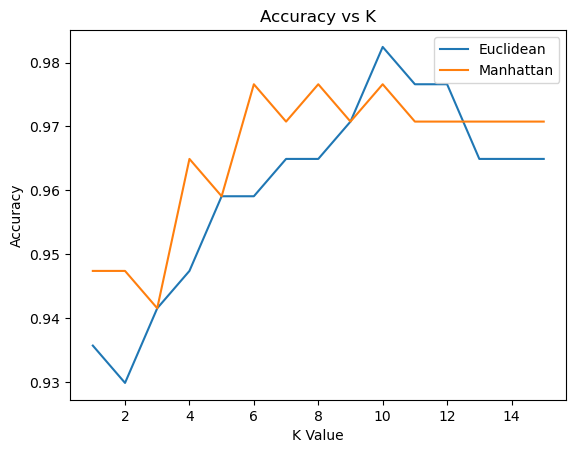

K=1 | Euclidean=0.936 | Manhattan=0.947
K=2 | Euclidean=0.930 | Manhattan=0.947
K=3 | Euclidean=0.942 | Manhattan=0.942
K=4 | Euclidean=0.947 | Manhattan=0.965
K=5 | Euclidean=0.959 | Manhattan=0.959
K=6 | Euclidean=0.959 | Manhattan=0.977
K=7 | Euclidean=0.965 | Manhattan=0.971
K=8 | Euclidean=0.965 | Manhattan=0.977
K=9 | Euclidean=0.971 | Manhattan=0.971
K=10 | Euclidean=0.982 | Manhattan=0.977
K=11 | Euclidean=0.977 | Manhattan=0.971
K=12 | Euclidean=0.977 | Manhattan=0.971
K=13 | Euclidean=0.965 | Manhattan=0.971
K=14 | Euclidean=0.965 | Manhattan=0.971
K=15 | Euclidean=0.965 | Manhattan=0.971


In [1]:
#Step 1: Load Dataset
from sklearn.datasets import load_breast_cancer
import pandas as pd
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target
# Step 2: Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# Step 3: Train KNN for Different K Values
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
k_values = range(1, 16)
accuracy_euclidean = []
accuracy_manhattan = []
for k in k_values:
    # Euclidean
    model_e = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    model_e.fit(X_train, y_train)
    pred_e = model_e.predict(X_test)
    accuracy_euclidean.append(accuracy_score(y_test, pred_e))
    
    # Manhattan
    model_m = KNeighborsClassifier(n_neighbors=k, metric='manhattan')
    model_m.fit(X_train, y_train)
    pred_m = model_m.predict(X_test)
    accuracy_manhattan.append(accuracy_score(y_test, pred_m))
# Step 4: Plot Accuracy vs K
import matplotlib.pyplot as plt
plt.plot(k_values, accuracy_euclidean, label='Euclidean')
plt.plot(k_values, accuracy_manhattan, label='Manhattan')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.legend()
plt.show()
#Step 5: Compare Results
for k, e_acc, m_acc in zip(k_values, accuracy_euclidean, accuracy_manhattan):
    print(f"K={k} | Euclidean={e_acc:.3f} | Manhattan={m_acc:.3f}")


In [ ]:
# Step 6: Explanation
#Why Accuracy Changes with K?
K = 1 (Low K)
Very sensitive to noise
Overfitting 
High variance → accuracy may fluctuate
Medium K (e.g., 5–9)
Balanced model 
Better generalization
Usually gives best accuracy
High K (e.g., 15)
Too smooth
Underfitting 
Ignores local patterns → lower accuracy
# Euclidean vs Manhattan
Euclidean Distance
Straight-line distance
Works well when data is continuous
Often performs slightly better
Manhattan Distance
Grid-based distance
More robust to outliers in some cases
# In this dataset:
Accuracy may be similar, but one may slightly outperform depending on data distribution.
#Final Conclusion
Best K is usually in the middle range (5–9)
Very small K → overfitting
Very large K → underfitting
Distance metric choice slightly affects performance but not drastically